<a href="https://colab.research.google.com/github/vrinda0115/PRODIGY_ML_03/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
import zipfile
import os

# Upload your zip file
uploaded = files.upload()

# Extract it
for fn in uploaded.keys():
    if fn.endswith('.zip'):
        zip_path = fn
        extract_path = fn.replace('.zip', '')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
            print(f"Extracted to {extract_path}")


Saving cats_dogs_light.zip to cats_dogs_light.zip
Extracted to cats_dogs_light


In [11]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Set image size and path
IMG_SIZE = 64
IMAGE_PATH = '/content/cats_dogs_light/cats_dogs_light/train'  # Change if needed

def load_data_mixed(folder, img_size):
    data, labels = [], []
    for filename in os.listdir(folder):
        if filename.lower().startswith('cat'):
            label = 0
        elif filename.lower().startswith('dog'):
            label = 1
        else:
            continue

        try:
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))
            data.append(img.flatten())
            labels.append(label)
        except:
            print(f"Skipping {filename}")
    return np.array(data), np.array(labels)

# Load dataset
X, y = load_data_mixed(IMAGE_PATH, IMG_SIZE)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM
clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.525
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.54      0.51        90
           1       0.58      0.51      0.54       110

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.52       200
weighted avg       0.53      0.52      0.53       200



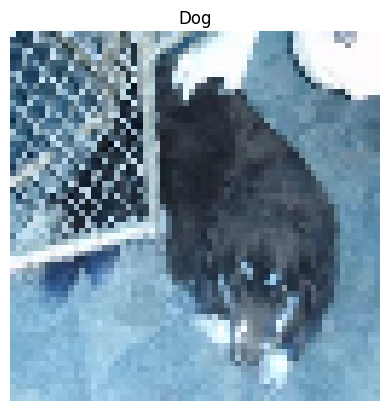

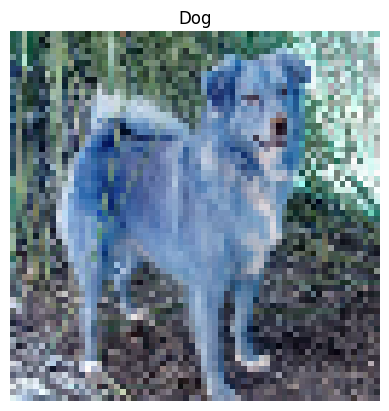

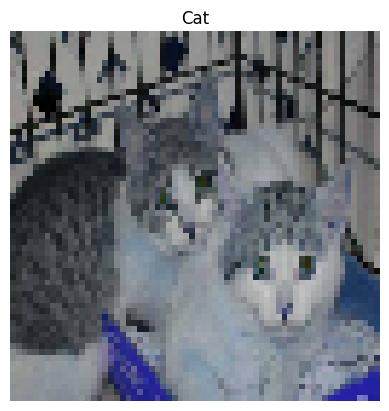

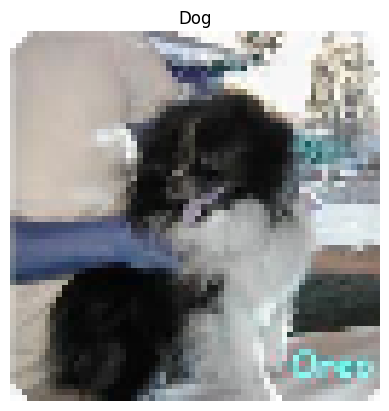

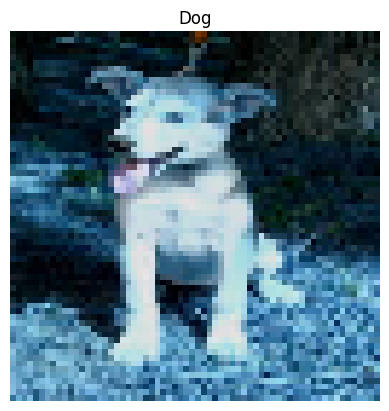

In [12]:
import matplotlib.pyplot as plt

for i in range(5):
    img = X[i].reshape(IMG_SIZE, IMG_SIZE, 3)
    label = 'Cat' if y[i] == 0 else 'Dog'
    plt.imshow(img.astype('uint8'))
    plt.title(label)
    plt.axis('off')
    plt.show()
